In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-0.188 – 0.969 sec
Baseline,off


Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


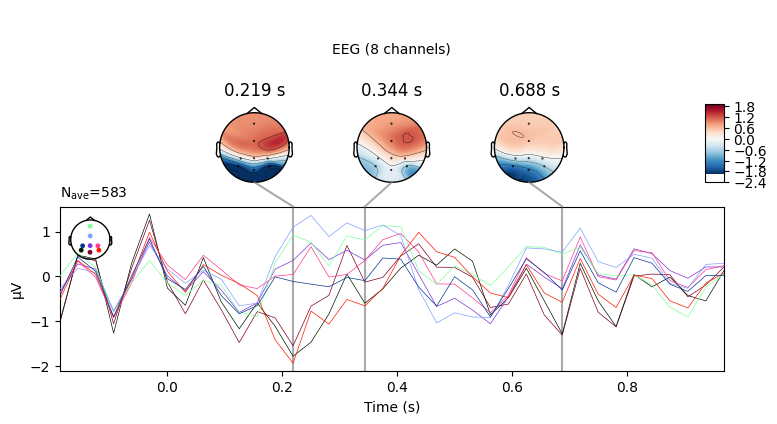

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('cupy')

X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train=='Target'
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test=='Target'

scaler = Scaler(with_mean=True, scalings='mean')
X_train = tl.tensor(scaler.fit_transform(X_train))
X_test = tl.tensor(scaler.transform(X_test))

In [20]:
from hoda.hoda import BTTDA, shrink, oas

n_blocks=16
hoda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
        max_iter=1024,
        rank=None,
        explain=1,
        tol=1e-6,
        init ='mlsvd',
        verbose=True,
        shrinkage=(0,0),
        toeplitz=(1,),
        solver='ratio_svd',
        keep_train_info=True,
    ),
    verbose=True
)

hoda.fit(X_train,y_train)

Fitting block 1/16...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8]

Fitting block 2/16...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8]

Fitting block 3/16...


...

  0%|          | 0/1024 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8]

Fitting block 16/16...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fit tucker model of rank [8, 8]



BTTDA(hoda_params={'explain': 1, 'init': 'mlsvd', 'keep_train_info': True,
                   'max_iter': 1024, 'rank': None, 'shrinkage': (0, 0),
                   'solver': 'ratio_svd', 'toeplitz': (1,), 'tol': 1e-06,
                   'verbose': True},
      n_blocks=16, verbose=True)

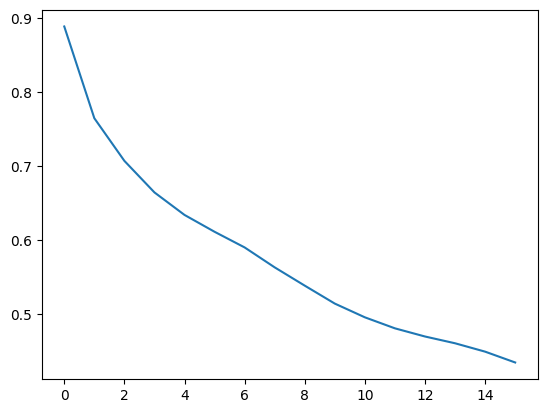

In [22]:
plt.plot(hoda.train_mse_)

In [10]:
from mne import EvokedArray
import cupy
"""
for i in range(block_rank):
    core = hoda.blocks_[i].transform(X_train)
    core = core[y_train].mean(axis=0)-core[~y_train].mean(axis=0)
    w_sp = hoda.blocks_[i].projs_[0].squeeze()
    w_tmp = hoda.blocks_[i].projs_[1].squeeze()
    w = np.atleast_2d(cupy.asnumpy(w_sp.T)).T @ core @ np.atleast_2d(cupy.asnumpy(w_tmp.T))
    w = EvokedArray(w, epochs.info, epochs.tmin)

w.plot_joint()
    #w.plot_image()
"""

'\nfor i in range(block_rank):\n    core = hoda.blocks_[i].transform(X_train)\n    core = core[y_train].mean(axis=0)-core[~y_train].mean(axis=0)\n    w_sp = hoda.blocks_[i].projs_[0].squeeze()\n    w_tmp = hoda.blocks_[i].projs_[1].squeeze()\n    w = np.atleast_2d(cupy.asnumpy(w_sp.T)).T @ core @ np.atleast_2d(cupy.asnumpy(w_tmp.T))\n    w = EvokedArray(w, epochs.info, epochs.tmin)\n\nw.plot_joint()\n    #w.plot_image()\n'

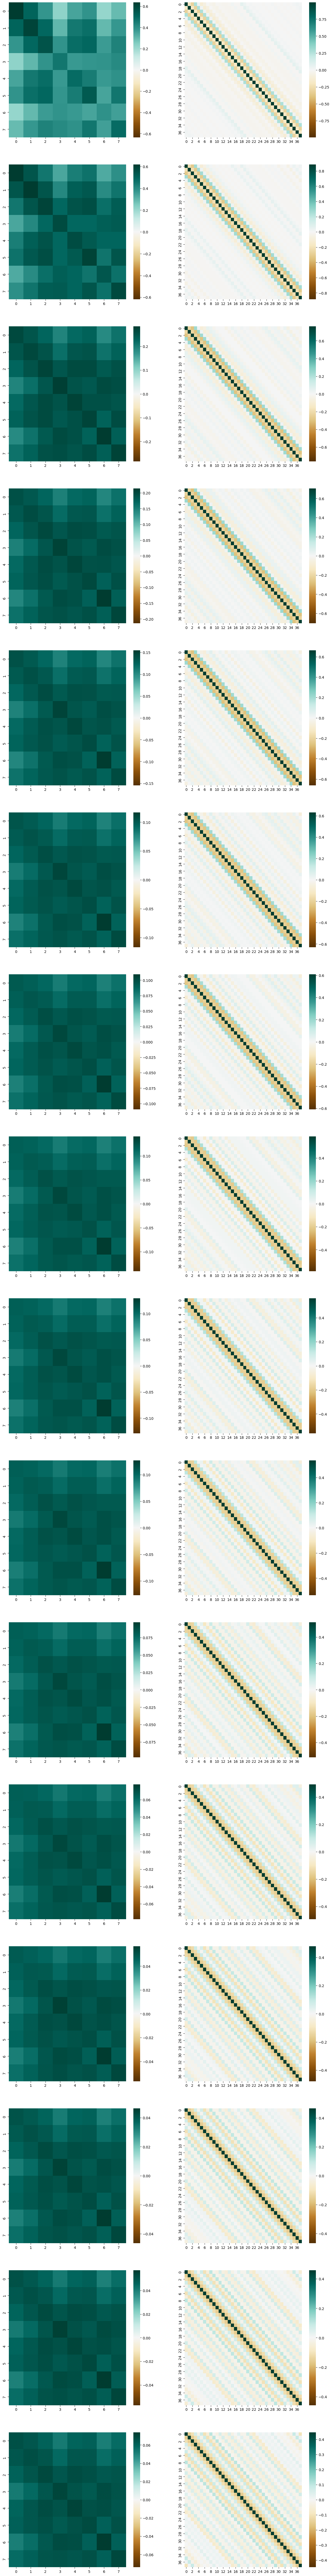

In [23]:
fig, axs = plt.subplots(n_blocks,2, figsize=(16,8*n_blocks))
axs = np.atleast_2d(axs)
for b in range(n_blocks):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])


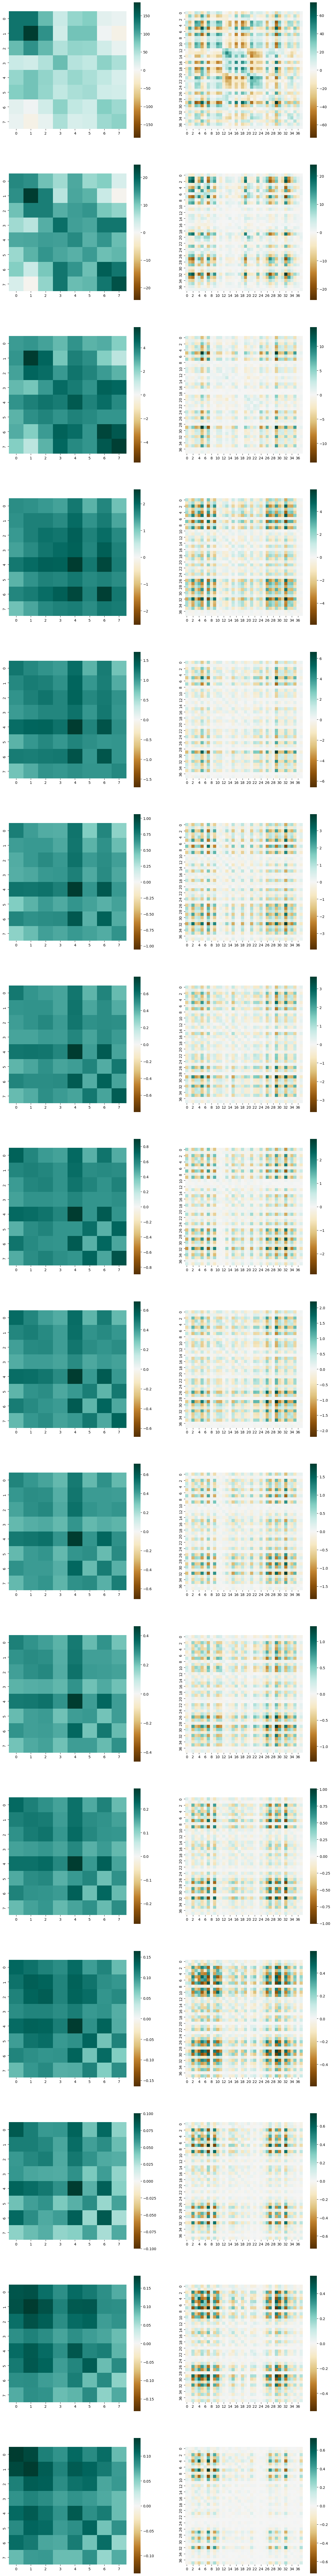

In [24]:
fig, axs = plt.subplots(n_blocks,2, figsize=(16,8*n_blocks))
axs = np.atleast_2d(axs)
for b in range(n_blocks):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_b_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')


In [25]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [26]:
print(X_train.shape)
print(X_train.shape[1]*X_train.shape[2])
print(Xt_train.shape)

(2100, 8, 38)
304
(2100, 1024)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [28]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

In [29]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9268457142857144

In [30]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8508848979591837